# ✈️ Airline Operations Analytics — Complete EDA

Beginner-friendly, professional exploratory data analysis on the cleaned airline dataset.

**Workflow:** Understand → KPIs → Trends → Airline → Airport → Route → Delays → Cancellations → Diversions → Outliers → Root Causes → Business Questions → Insights

# 1. Import libraries

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [167]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

# 2. Load cleaned data

In [168]:
file_path = r"D:\Data Analyst\EXCEL\api\processed\flights_2026_q1_cleaned.csv"
df = pd.read_csv(file_path)
print("Data loaded successfully")

Data loaded successfully


In [169]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1847242
Columns: 55


In [170]:
df.head()

,year,quarter,month,day_of_month,day_of_week,fl_date,mkt_unique_carrier,branded_code_share,mkt_carrier_airline_id,mkt_carrier,mkt_carrier_fl_num,origin,origin_city_name,origin_state_abr,origin_state_nm,dest,dest_city_name,dest_state_abr,dest_state_nm,crs_dep_time,dep_time,dep_delay,dep_delay_new,dep_del15,taxi_out,taxi_in,crs_arr_time,arr_time,arr_delay,arr_delay_new,arr_del15,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,flight_status,dep_time_at_cancellation,missing_operational_duration,extreme_dep_delay,extreme_arr_delay,is_cancelled,is_diverted,is_irregular_operation,is_departure_delayed,is_arrival_delayed,severe_departure_delay,severe_arrival_delay
0,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,1,JFK,"New York, NY",NY,New York,LAX,"Los Angeles, CA",CA,California,700,657.0,-3.0,0.0,0.0,67.0,11.0,1021,1104.0,43.0,43.0,1.0,0.0,NaN,0.0,381.0,427.0,349.0,2475.0,0.0,0.0,43.0,0.0,0.0,COMPLETED,NaN,False,False,False,0,0,0,0,1,0,0
1,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,10,LAX,"Los Angeles, CA",CA,California,JFK,"New York, NY",NY,New York,2130,2128.0,-2.0,0.0,0.0,16.0,6.0,551,520.0,-31.0,0.0,0.0,0.0,NaN,0.0,321.0,292.0,270.0,2475.0,NaN,NaN,NaN,NaN,NaN,COMPLETED,NaN,False,False,False,0,0,0,0,0,0,0
2,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,1002,MIA,"Miami, FL",FL,Florida,MSY,"New Orleans, LA",LA,Louisiana,2245,2252.0,7.0,7.0,0.0,16.0,3.0,2359,2356.0,-3.0,0.0,0.0,0.0,NaN,0.0,134.0,124.0,105.0,674.0,NaN,NaN,NaN,NaN,NaN,COMPLETED,NaN,False,False,False,0,0,0,0,0,0,0
3,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,1003,DEN,"Denver, CO",CO,Colorado,MIA,"Miami, FL",FL,Florida,2338,2338.0,0.0,0.0,0.0,13.0,6.0,527,508.0,-19.0,0.0,0.0,0.0,NaN,0.0,229.0,210.0,191.0,1709.0,NaN,NaN,NaN,NaN,NaN,COMPLETED,NaN,False,False,False,0,0,0,0,0,0,0
4,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,1004,BOS,"Boston, MA",MA,Massachusetts,CLT,"Charlotte, NC",NC,North Carolina,757,756.0,-1.0,0.0,0.0,26.0,4.0,1030,1023.0,-7.0,0.0,0.0,0.0,NaN,0.0,153.0,147.0,117.0,728.0,NaN,NaN,NaN,NaN,NaN,COMPLETED,NaN,False,False,False,0,0,0,0,0,0,0


# 3. Understand the dataset

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1847242 entries, 0 to 1847241
Data columns (total 55 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   year                          int64  
 1   quarter                       int64  
 2   month                         int64  
 3   day_of_month                  int64  
 4   day_of_week                   int64  
 5   fl_date                       object 
 6   mkt_unique_carrier            object 
 7   branded_code_share            object 
 8   mkt_carrier_airline_id        int64  
 9   mkt_carrier                   object 
 10  mkt_carrier_fl_num            int64  
 11  origin                        object 
 12  origin_city_name              object 
 13  origin_state_abr              object 
 14  origin_state_nm               object 
 15  dest                          object 
 16  dest_city_name                object 
 17  dest_state_abr                object 
 18  dest_state_nm         

In [172]:
df.describe()

,year,quarter,month,day_of_month,day_of_week,mkt_carrier_airline_id,mkt_carrier_fl_num,crs_dep_time,dep_time,dep_delay,dep_delay_new,dep_del15,taxi_out,taxi_in,crs_arr_time,arr_time,arr_delay,arr_delay_new,arr_del15,cancelled,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,dep_time_at_cancellation,is_cancelled,is_diverted,is_irregular_operation,is_departure_delayed,is_arrival_delayed,severe_departure_delay,severe_arrival_delay
count,1847242.0,1847242.0,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.784775e+06,1.786268e+06,1.786268e+06,1.786268e+06,1.785251e+06,1.784287e+06,1.847242e+06,1.783398e+06,1.780194e+06,1.780194e+06,1.780194e+06,1.847242e+06,1.847242e+06,1.847232e+06,1.780185e+06,1.780185e+06,1.847242e+06,384426.000000,384426.000000,384426.000000,384426.000000,384426.000000,1527.000000,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06
mean,2026.0,1.0,2.039273e+00,1.556970e+01,4.018039e+00,1.982750e+04,2.764304e+03,1.322166e+03,1.329527e+03,1.393807e+01,1.758626e+01,2.182478e-01,1.920085e+01,8.785626e+00,1.504609e+03,1.473538e+03,7.249089e+00,1.734560e+01,2.159461e-01,3.373191e-02,2.564364e-03,1.480705e+02,1.415679e+02,1.135985e+02,8.080800e+02,26.771269,5.317260,14.499233,0.130366,29.269703,1559.886051,3.373191e-02,2.564364e-03,3.629627e-02,2.110438e-01,2.081081e-01,7.868217e-02,7.735478e-02
std,0.0,0.0,8.309906e-01,8.701216e+00,2.017735e+00,2.667073e+02,1.724521e+03,4.851421e+02,5.009625e+02,6.111301e+01,5.991430e+01,4.130566e-01,1.113011e+01,7.763654e+00,5.062326e+02,5.338911e+02,6.346866e+01,5.963412e+01,4.114772e-01,1.805383e-01,5.057459e-02,7.225020e+01,7.243144e+01,7.074440e+01,5.896536e+02,82.074800,41.409899,34.940501,4.280014,64.896116,542.915105,1.805383e-01,5.057459e-02,1.870264e-01,4.080495e-01,4.059547e-01,2.692421e-01,2.671536e-01
min,2026.0,1.0,1.000000e+00,1.000000e+00,1.000000e+00,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-6.600000e+01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,1.400000e+01,6.000000e+00,3.100000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2026.0,1.0,1.000000e+00,8.000000e+00,2.000000e+00,1.979000e+04,1.332000e+03,9.080000e+02,9.130000e+02,-7.000000e+00,0.000000e+00,0.000000e+00,1.300000e+01,5.000000e+00,1.115000e+03,1.058000e+03,-1.800000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.500000e+01,8.900000e+01,6.200000e+01,3.730000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1179.500000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2026.0,1.0,2.000000e+00,1.600000e+01,4.000000e+00,1.980500e+04,2.452000e+03,1.315000e+03,1.325000e+03,-2.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,7.000000e+00,1.524000e+03,1.511000e+03,-7.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.310000e+02,1.250000e+02,9.700000e+01,6.570000e+02,3.000000,0.000000,0.000000,0.000000,0.000000,1701.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2026.0,1.0,3.000000e+00,2.300000e+01,6.000000e+00,1.997700e+04,4.145000e+03,1.730000e+03,1.739000e+03,1.000000e+01,1.000000e+01,0.000000e+00,2.200000e+01,1.000000e+01,1.929000e+03,1.920000e+03,1.000000e+01,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.800000e+02,1.730000e+02,1.440000e+02,1.050000e+03,23.000000,0.000000,18.000000,0.000000,33.000000,2009.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2026.0,1.0,3.000000e+00,3.100000e+01,7.000000e+00,2.043600e+04,9.914000e+03,2.359000e+03,2.359000e+03,3.339000e+03,3.339000e+03,1.000000e+00,2.240000e+02,2.990000e+02,2.359000e+03,2.359000e+03,3.3

In [173]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [174]:
df.nunique().sort_values(ascending=False).head(20)

mkt_carrier_fl_num          6582
arr_delay                   1622
dep_delay                   1581
distance                    1567
arr_delay_new               1535
dep_delay_new               1525
arr_time                    1439
dep_time                    1435
crs_arr_time                1364
carrier_delay               1321
crs_dep_time                1266
late_aircraft_delay         1002
weather_delay                882
dep_time_at_cancellation     821
actual_elapsed_time          706
air_time                     669
nas_delay                    616
crs_elapsed_time             513
origin                       362
dest                         362
dtype: int64

# 4. Prepare date columns

In [175]:
df["fl_date"] = pd.to_datetime(df["fl_date"], errors="coerce")

In [176]:
df["year"] = df["fl_date"].dt.year
df["month"] = df["fl_date"].dt.month
df["month_name"] = df["fl_date"].dt.month_name()
df["day_of_week"] = df["fl_date"].dt.day_name()

In [177]:
print("Start date:", df["fl_date"].min())
print("End date:", df["fl_date"].max())

Start date: 2026-01-01 00:00:00
End date: 2026-03-31 00:00:00


# 5. Missing-value overview

In [178]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.head(20)

dep_time_at_cancellation    1845715
cancellation_code           1784931
nas_delay                   1462816
late_aircraft_delay         1462816
carrier_delay               1462816
security_delay              1462816
weather_delay               1462816
actual_elapsed_time           67057
air_time                      67057
arr_del15                     67048
arr_delay                     67048
arr_delay_new                 67048
arr_time                      63844
taxi_in                       62955
dep_time                      62467
taxi_out                      61991
dep_del15                     60974
dep_delay_new                 60974
dep_delay                     60974
crs_elapsed_time                 10
dtype: int64

In [179]:
missing_pct = (df.isna().mean() * 100).round(2)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
missing_pct.head(20)

dep_time_at_cancellation    99.92
cancellation_code           96.63
late_aircraft_delay         79.19
carrier_delay               79.19
security_delay              79.19
weather_delay               79.19
nas_delay                   79.19
arr_delay_new                3.63
arr_delay                    3.63
actual_elapsed_time          3.63
arr_del15                    3.63
air_time                     3.63
arr_time                     3.46
taxi_in                      3.41
dep_time                     3.38
taxi_out                     3.36
dep_delay                    3.30
dep_delay_new                3.30
dep_del15                    3.30
dtype: float64

# 6. Flight status

In [180]:
df["flight_status"].value_counts()

flight_status
COMPLETED    1780194
CANCELLED      62311
DIVERTED        4737
Name: count, dtype: int64

In [181]:
status_counts = df["flight_status"].value_counts()

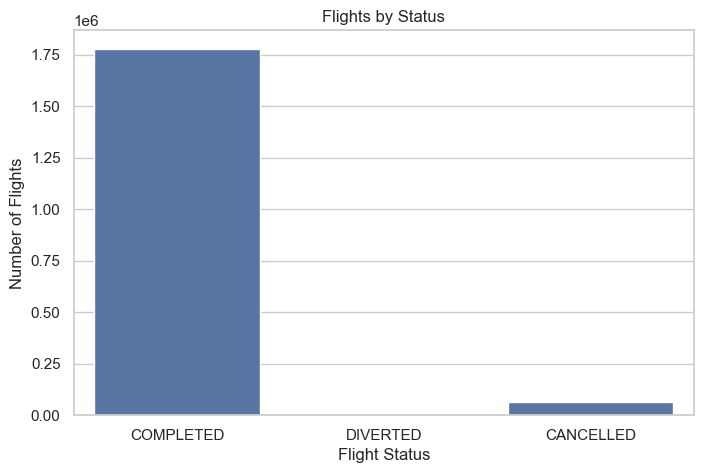

In [182]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="flight_status")
plt.title("Flights by Status")
plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")
plt.show()

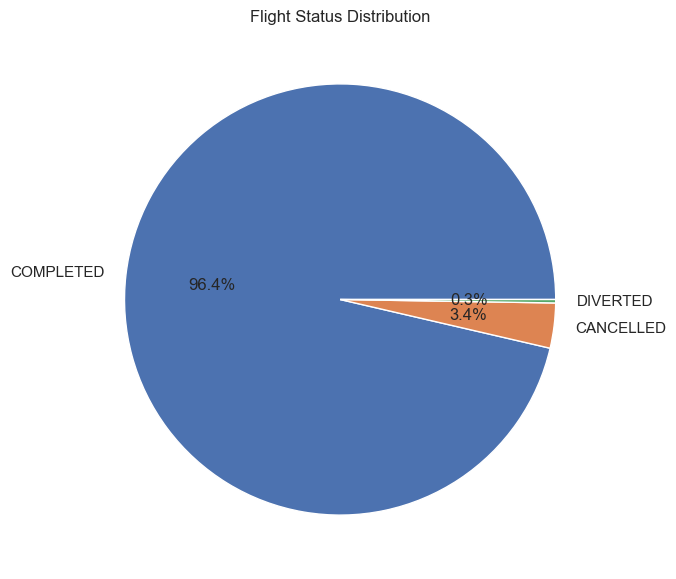

In [183]:
status_counts.plot(kind="pie", autopct="%1.1f%%", figsize=(7,7))
plt.title("Flight Status Distribution")
plt.ylabel("")
plt.show()

# 7. Core KPI's

In [184]:
total_flights = len(df)
completed_flights = (df["flight_status"] == "COMPLETED").sum()
cancelled_flights = (df["flight_status"] == "CANCELLED").sum()
diverted_flights = (df["flight_status"] == "DIVERTED").sum()

print("Total Flights:", total_flights)
print("Completed:", completed_flights)
print("Cancelled:", cancelled_flights)
print("Diverted:", diverted_flights)

Total Flights: 1847242
Completed: 1780194
Cancelled: 62311
Diverted: 4737


In [185]:
cancellation_rate = cancelled_flights / total_flights * 100
diversion_rate = diverted_flights / total_flights * 100

print("Cancellation Rate:", round(cancellation_rate,2), "%")
print("Diversion Rate:", round(diversion_rate,2), "%")

Cancellation Rate: 3.37 %
Diversion Rate: 0.26 %


In [186]:
completed_df = df[df["flight_status"] == "COMPLETED"].copy()

avg_dep_delay = completed_df["dep_delay"].mean()
avg_arr_delay = completed_df["arr_delay"].mean()

print("Average Departure Delay:", round(avg_dep_delay,2))
print("Average Arrival Delay:", round(avg_arr_delay,2))

Average Departure Delay: 13.81
Average Arrival Delay: 7.25


In [187]:
departure_delay_rate = completed_df["dep_delay"].ge(15).mean() * 100
arrival_delay_rate = completed_df["arr_delay"].ge(15).mean() * 100

print("Departure Delay Rate:", round(departure_delay_rate,2), "%")
print("Arrival Delay Rate:", round(arrival_delay_rate,2), "%")

Departure Delay Rate: 21.75 %
Arrival Delay Rate: 21.59 %


In [188]:
kpi = pd.DataFrame({
    "KPI": [
        "Total Flights","Completed Flights","Cancelled Flights","Diverted Flights",
        "Cancellation Rate","Diversion Rate",
        "Average Departure Delay","Average Arrival Delay",
        "Departure Delay Rate","Arrival Delay Rate"
    ],
    "Value": [
        total_flights,completed_flights,cancelled_flights,diverted_flights,
        round(cancellation_rate,2),round(diversion_rate,2),
        round(avg_dep_delay,2),round(avg_arr_delay,2),
        round(departure_delay_rate,2),round(arrival_delay_rate,2)
    ]
})
kpi

,KPI,Value
0,Total Flights,1847242.00
1,Completed Flights,1780194.00
2,Cancelled Flights,62311.00
3,Diverted Flights,4737.00
4,Cancellation Rate,3.37
5,Diversion Rate,0.26
6,Average Departure Delay,13.81
7,Average Arrival Delay,7.25
8,Departure Delay Rate,21.75
9,Arrival Delay Rate,21.59


# 8. Flight volume over time

## Business question: How does flight volume change over time?

In [189]:
monthly_flights = df.groupby(df["fl_date"].dt.to_period("M")).size()
monthly_flights.head()

fl_date
2026-01    602953
2026-02    568789
2026-03    675500
Freq: M, dtype: int64

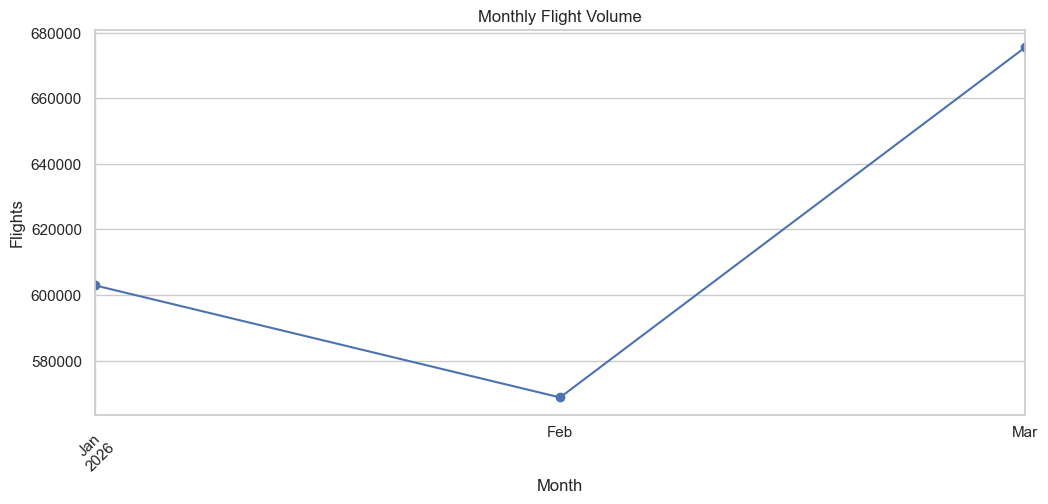

In [190]:
monthly_flights.plot(figsize=(12,5), marker="o")
plt.title("Monthly Flight Volume")
plt.xlabel("Month")
plt.ylabel("Flights")
plt.xticks(rotation=45)
plt.show()

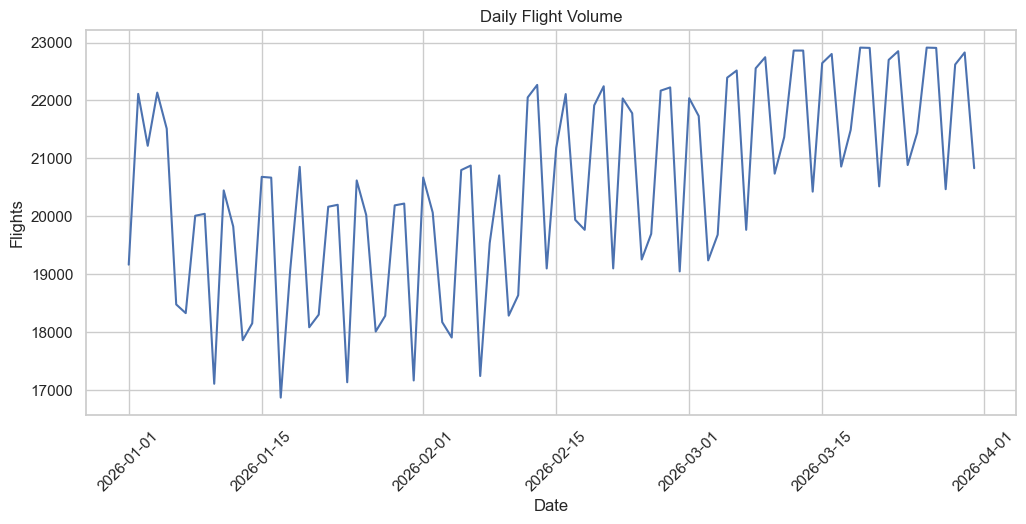

In [191]:
daily_flights = df.groupby("fl_date").size()
plt.figure(figsize=(12,5))
plt.plot(daily_flights.index, daily_flights.values)
plt.title("Daily Flight Volume")
plt.xlabel("Date")
plt.ylabel("Flights")
plt.xticks(rotation=45)
plt.show()

# 9. Day-of-week and monthly patterns

In [192]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_counts = df["day_of_week"].value_counts().reindex(day_order)
day_counts

day_of_week
Monday       279832
Tuesday      250644
Wednesday    233063
Thursday     278223
Friday       282049
Saturday     245173
Sunday       278258
Name: count, dtype: int64

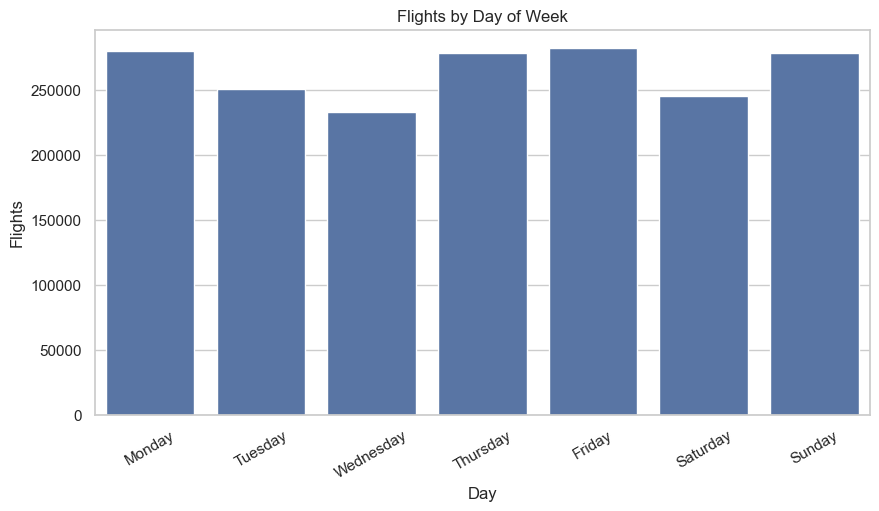

In [193]:
plt.figure(figsize=(10,5))
sns.barplot(x=day_counts.index, y=day_counts.values)
plt.title("Flights by Day of Week")
plt.xlabel("Day")
plt.ylabel("Flights")
plt.xticks(rotation=30)
plt.show()

In [194]:
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
month_counts = df["month_name"].value_counts().reindex(month_order)
month_counts

month_name
January      602953.0
February     568789.0
March        675500.0
April             NaN
May               NaN
June              NaN
July              NaN
August            NaN
September         NaN
October           NaN
November          NaN
December          NaN
Name: count, dtype: float64

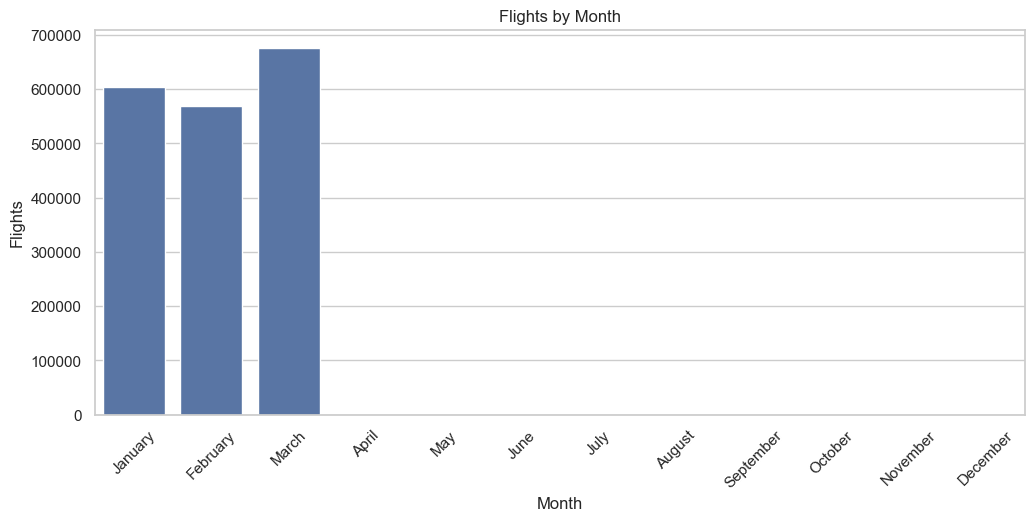

In [195]:
plt.figure(figsize=(12,5))
sns.barplot(x=month_counts.index, y=month_counts.values)
plt.title("Flights by Month")
plt.xlabel("Month")
plt.ylabel("Flights")
plt.xticks(rotation=45)
plt.show()

# 10. Airline performance

## Business questions: Which airlines have the most flights, cancellations and delays?

In [196]:
airline_flights = df["mkt_carrier"].value_counts()
airline_flights.head(15)

mkt_carrier
AA    483902
DL    386832
UA    358108
WN    327083
AS    116489
B6     57320
F9     50557
NK     36379
G4     30572
Name: count, dtype: int64

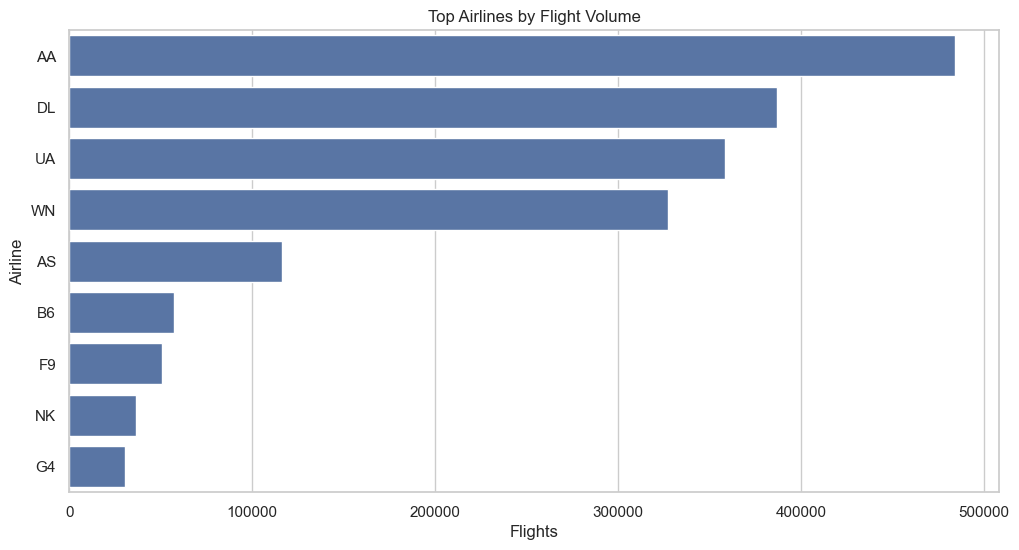

In [197]:
plt.figure(figsize=(12,6))
sns.barplot(x=airline_flights.head(15).values, y=airline_flights.head(15).index)
plt.title("Top Airlines by Flight Volume")
plt.xlabel("Flights")
plt.ylabel("Airline")
plt.show()

In [198]:
airline_cancel = df.groupby("mkt_carrier")["cancelled"].mean().mul(100).sort_values(ascending=False)
airline_cancel.head(15)

mkt_carrier
NK    8.584623
B6    5.251221
AA    4.741663
DL    3.703933
F9    2.779041
UA    2.570174
AS    1.852535
WN    1.730142
G4    1.566793
Name: cancelled, dtype: float64

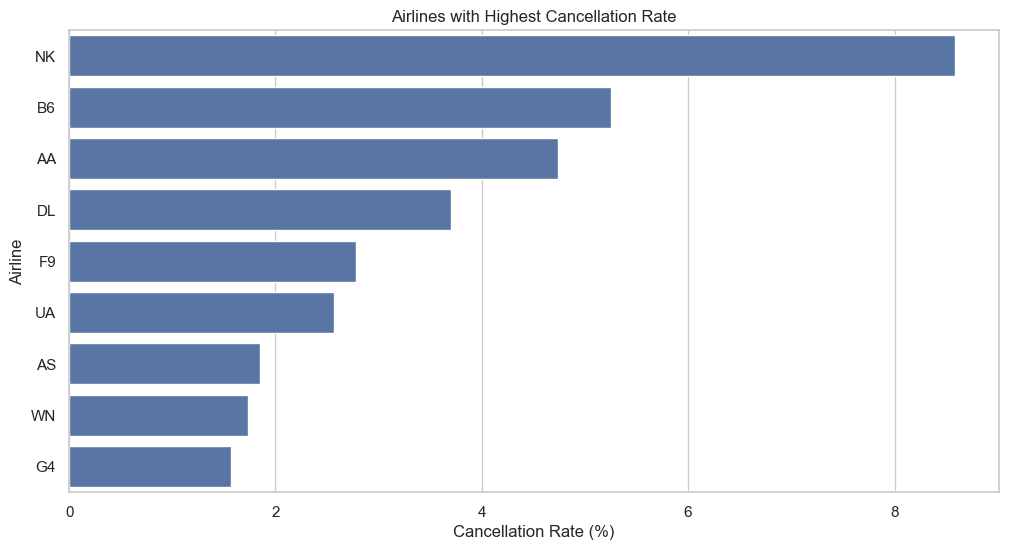

In [199]:
plt.figure(figsize=(12,6))
sns.barplot(x=airline_cancel.head(15).values, y=airline_cancel.head(15).index)
plt.title("Airlines with Highest Cancellation Rate")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Airline")
plt.show()

In [200]:
airline_delay = completed_df.groupby("mkt_carrier")["arr_delay"].mean().sort_values(ascending=False)
airline_delay.head(15)

mkt_carrier
NK    19.661396
B6    15.625995
G4    13.490645
F9    13.014408
AA    10.322157
UA     6.235863
DL     5.853817
WN     3.200954
AS     2.175787
Name: arr_delay, dtype: float64

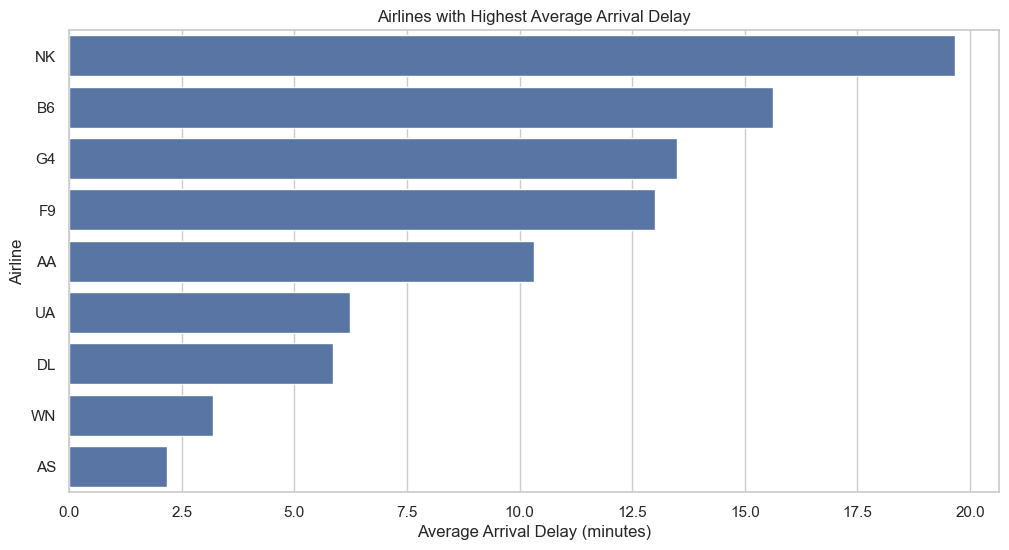

In [201]:
plt.figure(figsize=(12,6))
sns.barplot(x=airline_delay.head(15).values, y=airline_delay.head(15).index)
plt.title("Airlines with Highest Average Arrival Delay")
plt.xlabel("Average Arrival Delay (minutes)")
plt.ylabel("Airline")
plt.show()

In [202]:
airline_delay_rate = completed_df.groupby("mkt_carrier")["arr_delay"].apply(lambda x: (x >= 15).mean()*100).sort_values(ascending=False)
airline_delay_rate.head(15)

mkt_carrier
NK    35.423632
B6    31.207415
F9    26.753072
G4    24.929131
AA    23.042887
DL    20.131893
WN    20.071696
UA    19.804200
AS    18.582650
Name: arr_delay, dtype: float64

# 11. Airport analysis

## Business question: Which airports are operational hotspots?

In [203]:
top_origins = df["origin"].value_counts().head(15)
top_origins

origin
ORD    88327
ATL    82965
DEN    74619
DFW    72321
CLT    55461
PHX    51866
LAX    45488
MCO    42632
LAS    42030
IAH    41268
LGA    40594
SEA    39847
DCA    36466
SFO    34732
EWR    33544
Name: count, dtype: int64

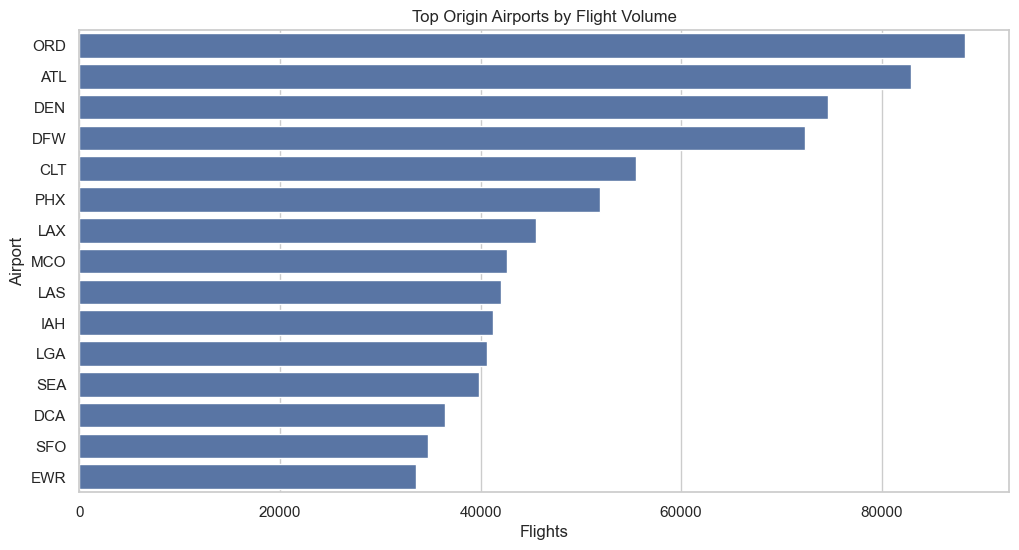

In [204]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_origins.values, y=top_origins.index)
plt.title("Top Origin Airports by Flight Volume")
plt.xlabel("Flights")
plt.ylabel("Airport")
plt.show()

In [205]:
airport_delay = completed_df.groupby("origin")["dep_delay"].mean().sort_values(ascending=False)
airport_delay.head(15)

origin
PAH    75.352113
ART    71.723529
JST    66.932515
MQT    57.000000
IMT    55.807229
BGM    48.093023
LWB    47.682540
HGR    47.346154
EAU    44.930556
PLN    42.600000
FOD    41.680556
LAF    40.963504
CMX    40.394904
PBG    40.120968
CIU    39.059603
Name: dep_delay, dtype: float64

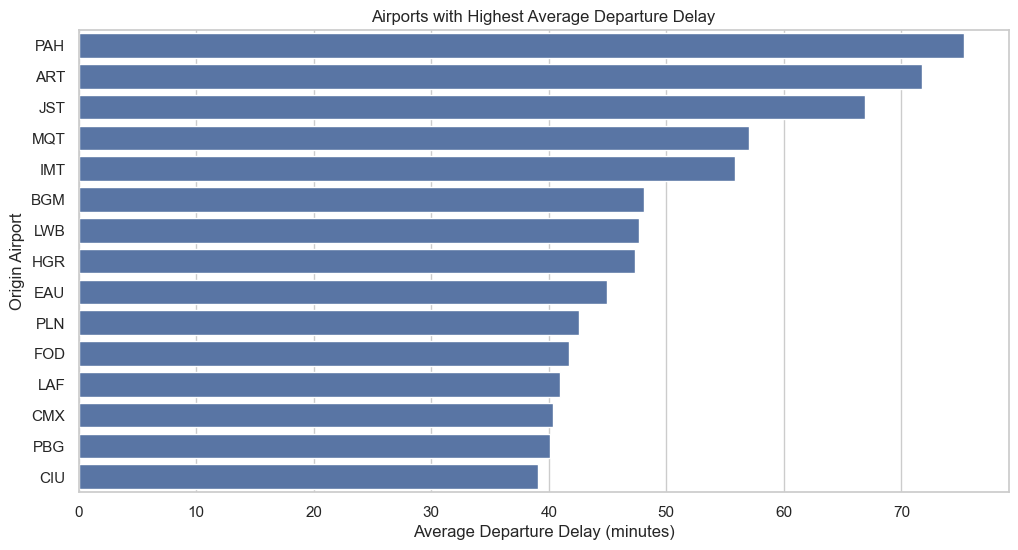

In [206]:
plt.figure(figsize=(12,6))
sns.barplot(x=airport_delay.head(15).values, y=airport_delay.head(15).index)
plt.title("Airports with Highest Average Departure Delay")
plt.xlabel("Average Departure Delay (minutes)")
plt.ylabel("Origin Airport")
plt.show()

In [207]:
arrival_airport_delay = completed_df.groupby("dest")["arr_delay"].mean().sort_values(ascending=False)
arrival_airport_delay.head(15)

dest
PAH    72.013889
JST    71.737500
LWB    65.384615
SHD    59.250000
VCT    51.272727
BGM    51.116279
CMX    47.512658
MQT    46.076642
IMT    42.824242
CIU    38.520000
MGW    37.928571
LAF    36.948148
ESC    35.000000
ITH    34.767507
AZO    34.281250
Name: arr_delay, dtype: float64

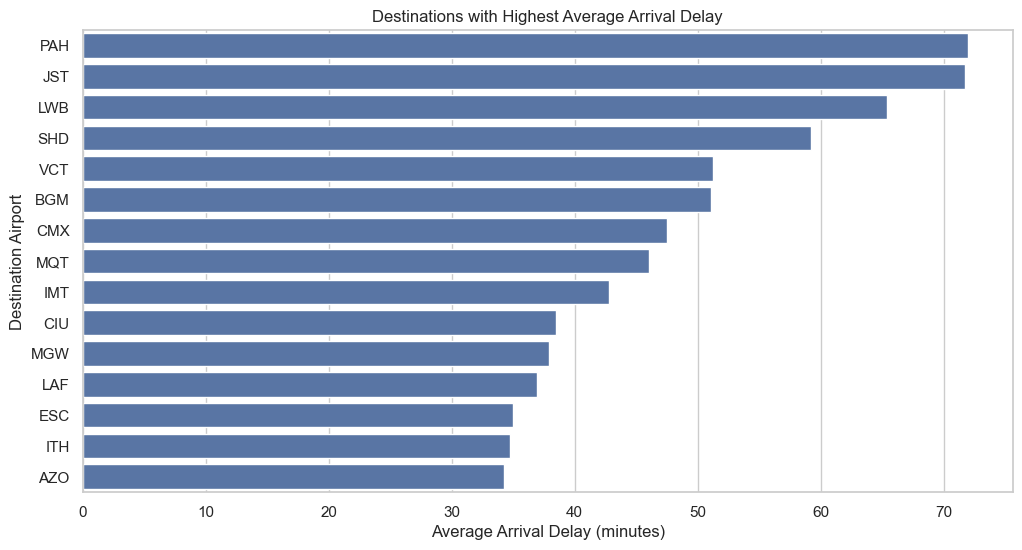

In [208]:
plt.figure(figsize=(12,6))
sns.barplot(x=arrival_airport_delay.head(15).values, y=arrival_airport_delay.head(15).index)
plt.title("Destinations with Highest Average Arrival Delay")
plt.xlabel("Average Arrival Delay (minutes)")
plt.ylabel("Destination Airport")
plt.show()

# 12. Route analysis

## Business question: Which routes have the highest operational problems?

In [209]:
df["route"] = df["origin"].astype(str) + " → " + df["dest"].astype(str)

In [210]:
top_routes = df["route"].value_counts().head(15)
top_routes

route
ORD → LGA    2835
LGA → ORD    2830
LAX → SFO    2756
SFO → LAX    2755
OGG → HNL    2537
HNL → OGG    2536
LAX → JFK    2400
JFK → LAX    2395
DEN → PHX    2376
PHX → DEN    2375
BOS → DCA    2294
DCA → BOS    2293
LAX → LAS    2157
LAS → LAX    2153
ATL → MCO    2147
Name: count, dtype: int64

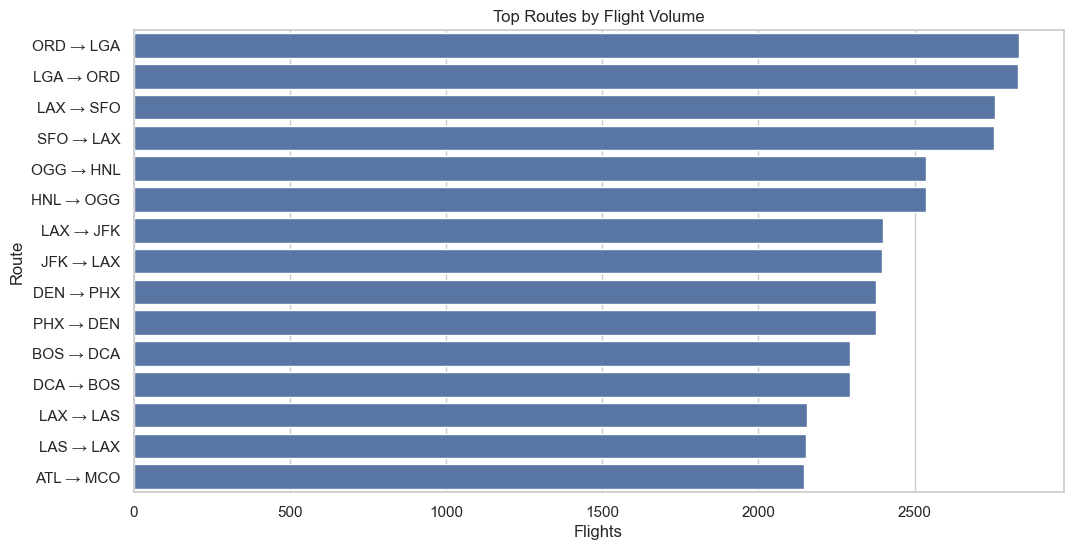

In [211]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_routes.values, y=top_routes.index)
plt.title("Top Routes by Flight Volume")
plt.xlabel("Flights")
plt.ylabel("Route")
plt.show()

In [212]:
# route_delay = completed_df.groupby("route")["arr_delay"].mean().sort_values(ascending=False)
# route_delay.head(15)

In [213]:
# plt.figure(figsize=(12,6))
# sns.barplot(x=route_delay.head(15).values, y=route_delay.head(15).index)
# plt.title("Routes with Highest Average Arrival Delay")
# plt.xlabel("Average Arrival Delay (minutes)")
# plt.ylabel("Route")
# plt.show()

# 13. Delay distributions

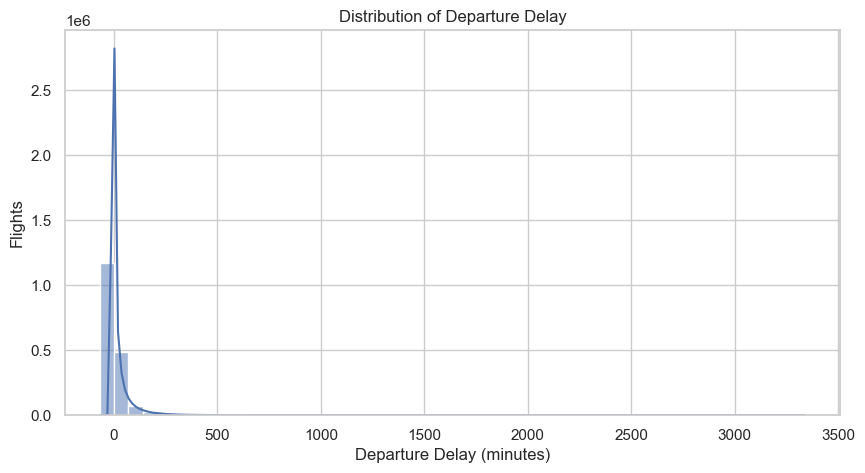

In [214]:
plt.figure(figsize=(10,5))
sns.histplot(completed_df["dep_delay"].dropna(), bins=50, kde=True)
plt.title("Distribution of Departure Delay")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Flights")
plt.show()

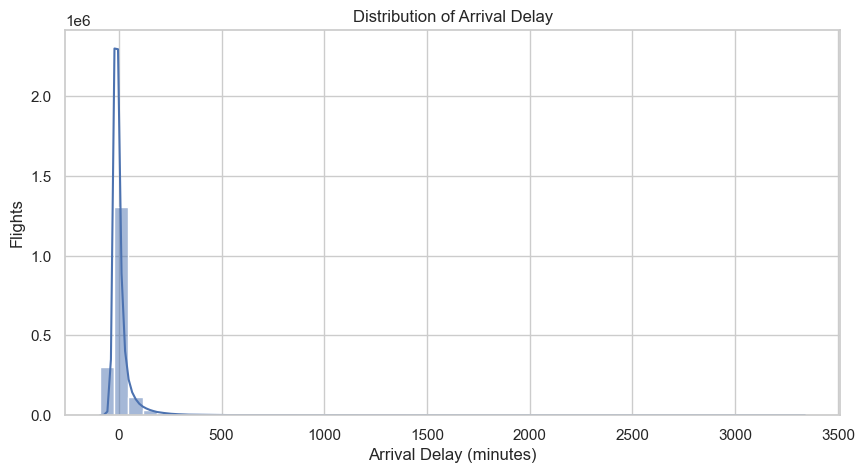

In [215]:
plt.figure(figsize=(10,5))
sns.histplot(completed_df["arr_delay"].dropna(), bins=50, kde=True)
plt.title("Distribution of Arrival Delay")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Flights")
plt.show()

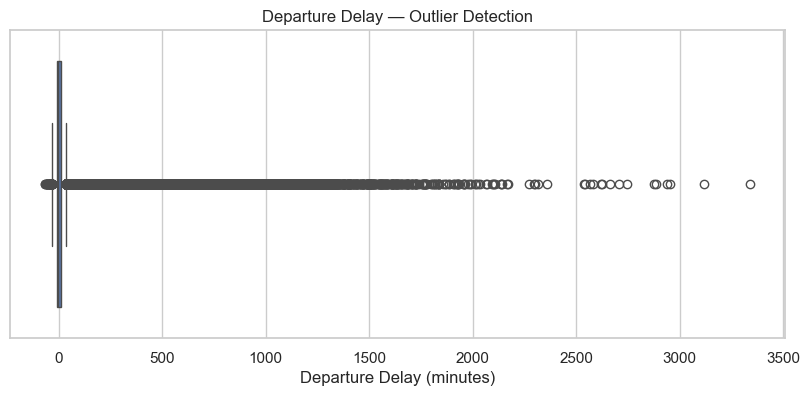

In [216]:
plt.figure(figsize=(10,4))
sns.boxplot(x=completed_df["dep_delay"])
plt.title("Departure Delay — Outlier Detection")
plt.xlabel("Departure Delay (minutes)")
plt.show()

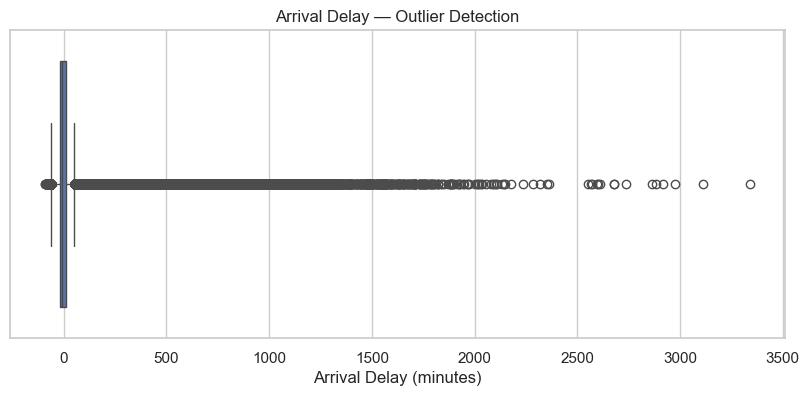

In [217]:
plt.figure(figsize=(10,4))
sns.boxplot(x=completed_df["arr_delay"])
plt.title("Arrival Delay — Outlier Detection")
plt.xlabel("Arrival Delay (minutes)")
plt.show()

# 14. IQR outlier analysis

IQR = Q3 − Q1. Outliers are values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR. These are investigated, not automatically deleted.

In [218]:
q1_dep = completed_df["dep_delay"].quantile(0.25)
q3_dep = completed_df["dep_delay"].quantile(0.75)
iqr_dep = q3_dep - q1_dep

print("Q1:", q1_dep)
print("Q3:", q3_dep)
print("IQR:", iqr_dep)

Q1: -7.0
Q3: 10.0
IQR: 17.0


In [219]:
lower_dep = q1_dep - 1.5 * iqr_dep
upper_dep = q3_dep + 1.5 * iqr_dep

print("Lower bound:", lower_dep)
print("Upper bound:", upper_dep)

Lower bound: -32.5
Upper bound: 35.5


In [220]:
dep_outliers = completed_df[(completed_df["dep_delay"] < lower_dep) | (completed_df["dep_delay"] > upper_dep)]
print("Departure delay outliers:", len(dep_outliers))

Departure delay outliers: 226904


In [221]:
print("Departure outlier %:", round(len(dep_outliers)/len(completed_df)*100,2))

Departure outlier %: 12.75


In [222]:
q1_arr = completed_df["arr_delay"].quantile(0.25)
q3_arr = completed_df["arr_delay"].quantile(0.75)
iqr_arr = q3_arr - q1_arr

print("Q1:", q1_arr)
print("Q3:", q3_arr)
print("IQR:", iqr_arr)

Q1: -18.0
Q3: 10.0
IQR: 28.0


In [223]:
lower_arr = q1_arr - 1.5 * iqr_arr
upper_arr = q3_arr + 1.5 * iqr_arr

print("Lower bound:", lower_arr)
print("Upper bound:", upper_arr)

Lower bound: -60.0
Upper bound: 52.0


In [224]:
arr_outliers = completed_df[(completed_df["arr_delay"] < lower_arr) | (completed_df["arr_delay"] > upper_arr)]
print("Arrival delay outliers:", len(arr_outliers))

Arrival delay outliers: 161742


In [225]:
print("Arrival outlier %:", round(len(arr_outliers)/len(completed_df)*100,2))

Arrival outlier %: 9.09


In [226]:
top_departure_delays = completed_df.sort_values("dep_delay", ascending=False).head(20)
top_departure_delays[["fl_date","mkt_carrier","origin","dest","dep_delay","arr_delay"]]

,fl_date,mkt_carrier,origin,dest,dep_delay,arr_delay
545981,2026-01-29,AA,SDF,DFW,3339.0,3339.0
943931,2026-02-18,AA,MFE,DFW,3120.0,3113.0
164767,2026-01-09,AA,AUS,PHL,2954.0,2975.0
1069948,2026-02-24,AA,HNL,LAX,2937.0,2919.0
1781179,2026-03-29,AA,BDL,MIA,2888.0,2862.0
1412313,2026-03-12,AA,BNA,CLT,2874.0,2882.0
932419,2026-02-17,DL,SDF,DTW,2748.0,2738.0
124764,2026-01-07,AA,MCI,PHX,2706.0,2680.0
1342971,2026-03-09,AA,OMA,DFW,2663.0,2678.0
1366117,2026-03-10,AA,AUS,PHL,2625.0,2610.0


In [227]:
top_arrival_delays = completed_df.sort_values("arr_delay", ascending=False).head(20)
top_arrival_delays[["fl_date","mkt_carrier","origin","dest","dep_delay","arr_delay"]]

,fl_date,mkt_carrier,origin,dest,dep_delay,arr_delay
545981,2026-01-29,AA,SDF,DFW,3339.0,3339.0
943931,2026-02-18,AA,MFE,DFW,3120.0,3113.0
164767,2026-01-09,AA,AUS,PHL,2954.0,2975.0
1069948,2026-02-24,AA,HNL,LAX,2937.0,2919.0
1412313,2026-03-12,AA,BNA,CLT,2874.0,2882.0
1781179,2026-03-29,AA,BDL,MIA,2888.0,2862.0
932419,2026-02-17,DL,SDF,DTW,2748.0,2738.0
124764,2026-01-07,AA,MCI,PHX,2706.0,2680.0
1342971,2026-03-09,AA,OMA,DFW,2663.0,2678.0
1366117,2026-03-10,AA,AUS,PHL,2625.0,2610.0


# 15. Delay causes

In [228]:
delay_columns = ["carrier_delay","weather_delay","nas_delay","security_delay","late_aircraft_delay"]

In [229]:
delay_totals = completed_df[delay_columns].sum().sort_values(ascending=False)
delay_totals

late_aircraft_delay    11252035.0
carrier_delay          10291572.0
nas_delay               5573882.0
weather_delay           2044093.0
security_delay            50116.0
dtype: float64

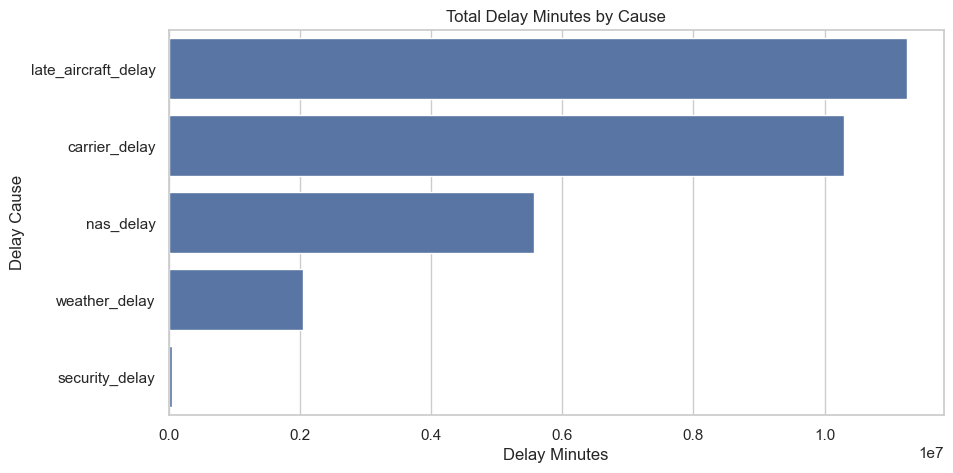

In [230]:
plt.figure(figsize=(10,5))
sns.barplot(x=delay_totals.values, y=delay_totals.index)
plt.title("Total Delay Minutes by Cause")
plt.xlabel("Delay Minutes")
plt.ylabel("Delay Cause")
plt.show()

In [231]:
delay_percentage = (delay_totals / delay_totals.sum() * 100).round(2)
delay_percentage

late_aircraft_delay    38.52
carrier_delay          35.23
nas_delay              19.08
weather_delay           7.00
security_delay          0.17
dtype: float64

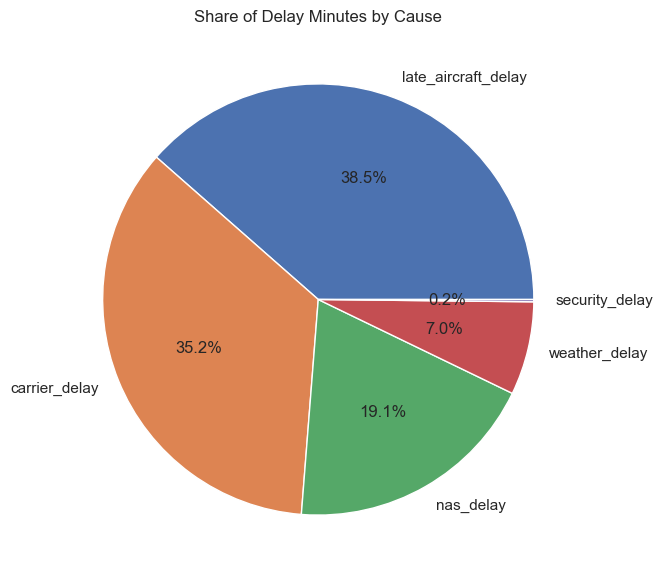

In [232]:
delay_percentage.plot(kind="pie", autopct="%1.1f%%", figsize=(7,7))
plt.title("Share of Delay Minutes by Cause")
plt.ylabel("")
plt.show()

In [233]:
airline_delay_causes = completed_df.groupby("mkt_carrier")[delay_columns].sum()
airline_delay_causes.head()

,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
mkt_carrier,,,,,
AA,3103436.0,837606.0,1281853.0,18212.0,3917227.0
AS,411193.0,84526.0,213728.0,3379.0,475514.0
B6,344901.0,37005.0,283291.0,3454.0,588586.0
DL,2808001.0,545189.0,1051938.0,4258.0,1415570.0
F9,315950.0,32132.0,219857.0,0.0,541871.0


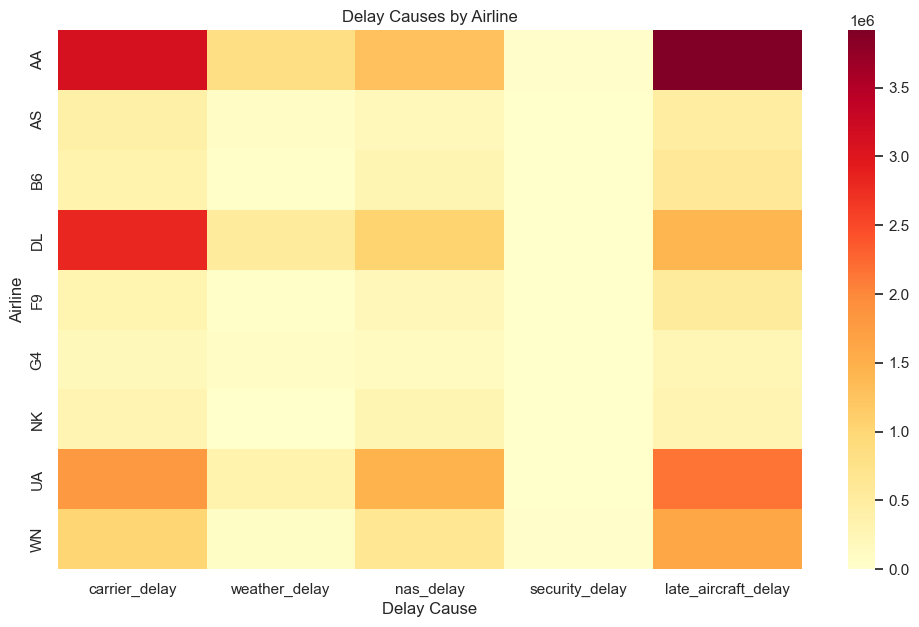

In [234]:
plt.figure(figsize=(12,7))
sns.heatmap(airline_delay_causes, cmap="YlOrRd")
plt.title("Delay Causes by Airline")
plt.xlabel("Delay Cause")
plt.ylabel("Airline")
plt.show()

# 16. Cancellation analysis

## Business questions: When and where are cancellations highest?

In [235]:
cancelled_df = df[df["cancelled"] == 1].copy()
print("Cancelled flights:", len(cancelled_df))

Cancelled flights: 62311


In [236]:
cancel_by_airline = cancelled_df["mkt_carrier"].value_counts().head(15)
cancel_by_airline

mkt_carrier
AA    22945
DL    14328
UA     9204
WN     5659
NK     3123
B6     3010
AS     2158
F9     1405
G4      479
Name: count, dtype: int64

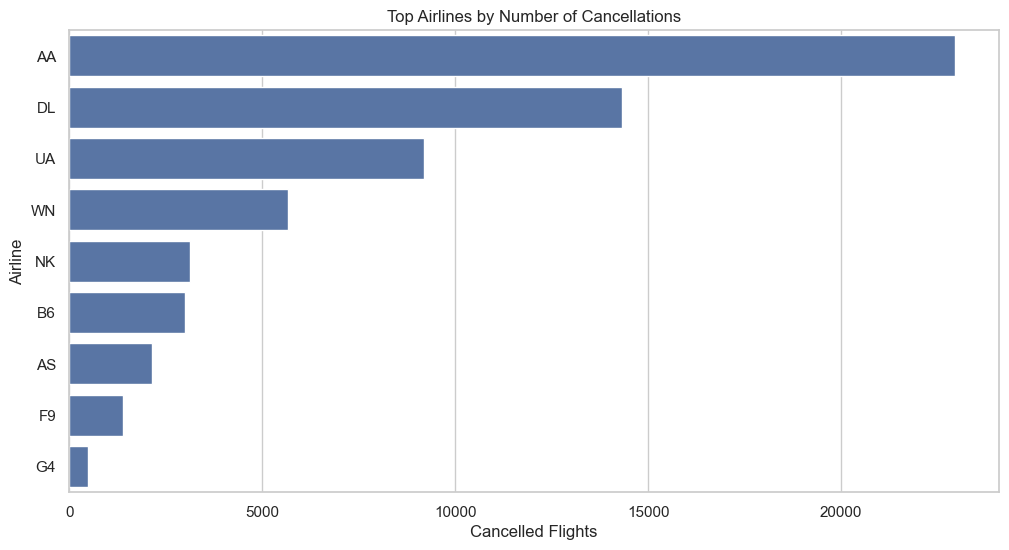

In [237]:
plt.figure(figsize=(12,6))
sns.barplot(x=cancel_by_airline.values, y=cancel_by_airline.index)
plt.title("Top Airlines by Number of Cancellations")
plt.xlabel("Cancelled Flights")
plt.ylabel("Airline")
plt.show()

In [238]:
cancel_by_origin = cancelled_df["origin"].value_counts().head(15)
cancel_by_origin

origin
LGA    3611
DFW    3330
ORD    3269
CLT    3010
ATL    2736
DCA    2275
BOS    1952
JFK    1861
EWR    1835
MCO    1495
PHL    1453
FLL    1199
DTW    1056
DEN    1023
MIA     995
Name: count, dtype: int64

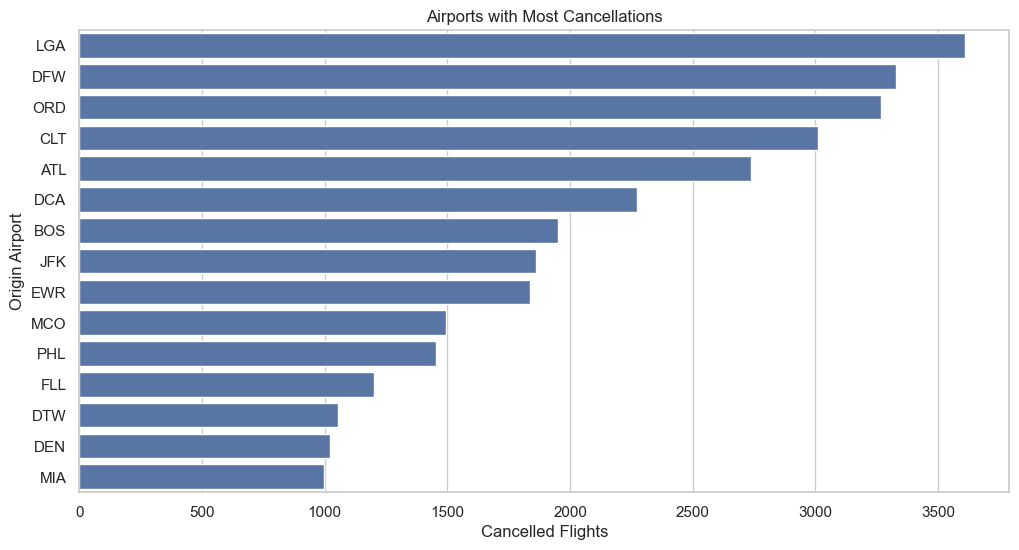

In [239]:
plt.figure(figsize=(12,6))
sns.barplot(x=cancel_by_origin.values, y=cancel_by_origin.index)
plt.title("Airports with Most Cancellations")
plt.xlabel("Cancelled Flights")
plt.ylabel("Origin Airport")
plt.show()

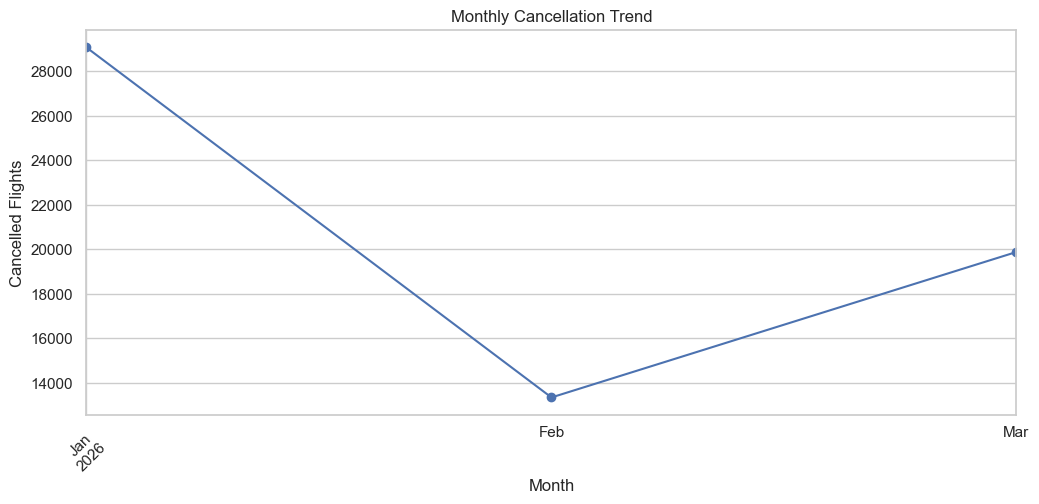

In [240]:
monthly_cancelled = cancelled_df.groupby(cancelled_df["fl_date"].dt.to_period("M")).size()
monthly_cancelled.plot(figsize=(12,5), marker="o")
plt.title("Monthly Cancellation Trend")
plt.xlabel("Month")
plt.ylabel("Cancelled Flights")
plt.xticks(rotation=45)
plt.show()

# 17. Diversion analysis

In [241]:
diverted_df = df[df["diverted"] == 1].copy()
print("Diverted flights:", len(diverted_df))

Diverted flights: 4737


In [242]:
diverted_by_airline = diverted_df["mkt_carrier"].value_counts().head(15)
diverted_by_airline

mkt_carrier
AA    1492
UA     998
DL     840
WN     624
AS     386
B6     153
G4     108
F9      81
NK      55
Name: count, dtype: int64

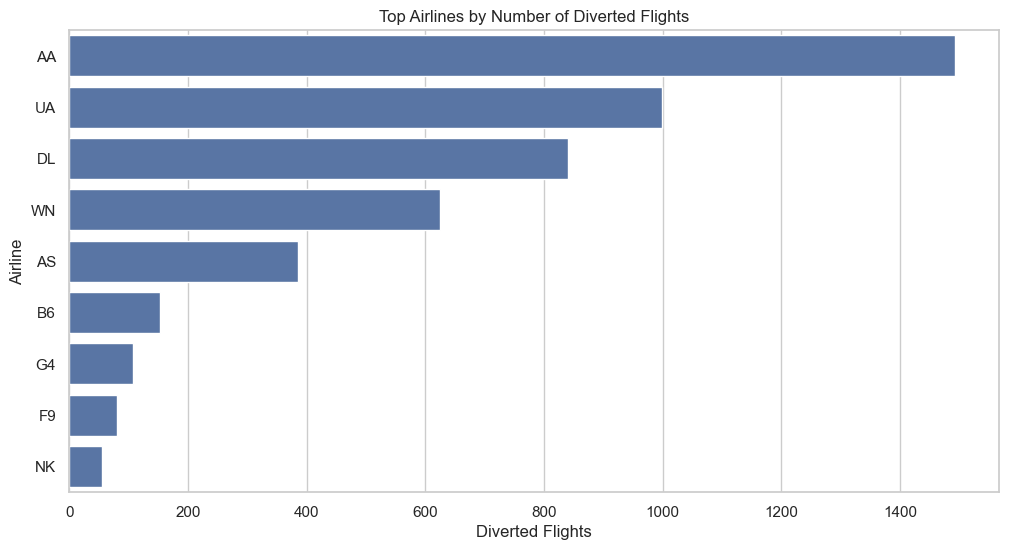

In [243]:
plt.figure(figsize=(12,6))
sns.barplot(x=diverted_by_airline.values, y=diverted_by_airline.index)
plt.title("Top Airlines by Number of Diverted Flights")
plt.xlabel("Diverted Flights")
plt.ylabel("Airline")
plt.show()

# 18. Operational relationships

## Do departure delays carry into arrival delays?

In [244]:
sample_df = completed_df.sample(min(10000, len(completed_df)), random_state=42)

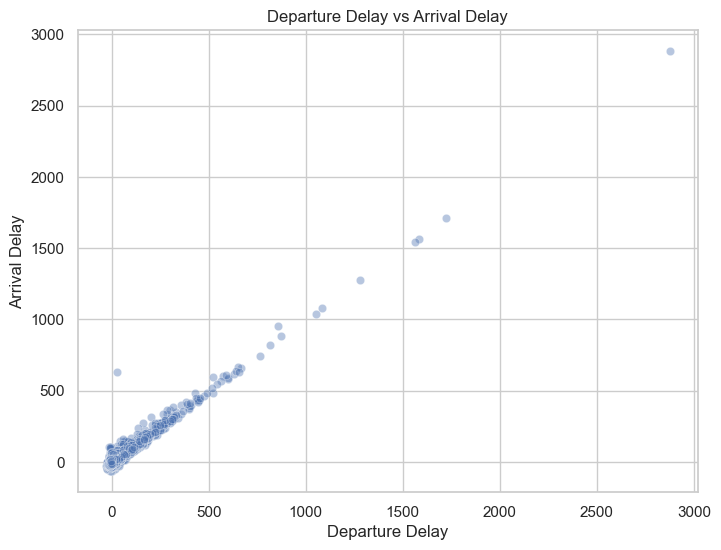

In [245]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=sample_df, x="dep_delay", y="arr_delay", alpha=0.4)
plt.title("Departure Delay vs Arrival Delay")
plt.xlabel("Departure Delay")
plt.ylabel("Arrival Delay")
plt.show()

In [246]:
completed_df[["dep_delay","arr_delay"]].corr()

,dep_delay,arr_delay
dep_delay,1.000000,0.969316
arr_delay,0.969316,1.000000


## Scheduled vs actual duration

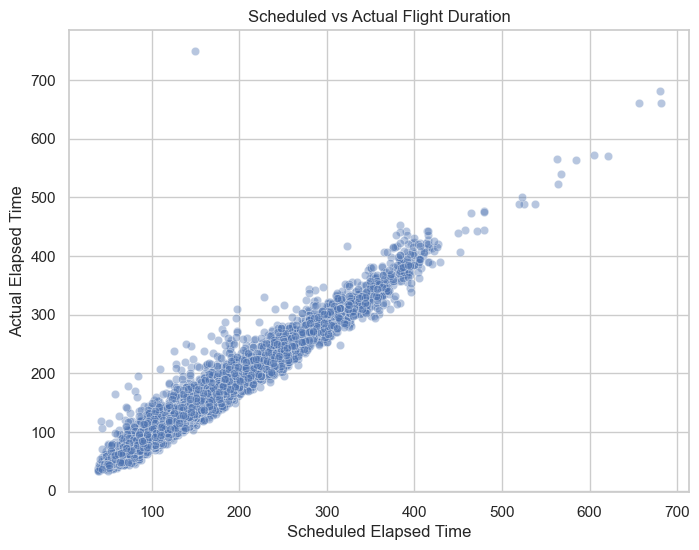

In [247]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=sample_df, x="crs_elapsed_time", y="actual_elapsed_time", alpha=0.4)
plt.title("Scheduled vs Actual Flight Duration")
plt.xlabel("Scheduled Elapsed Time")
plt.ylabel("Actual Elapsed Time")
plt.show()

## Distance vs air time

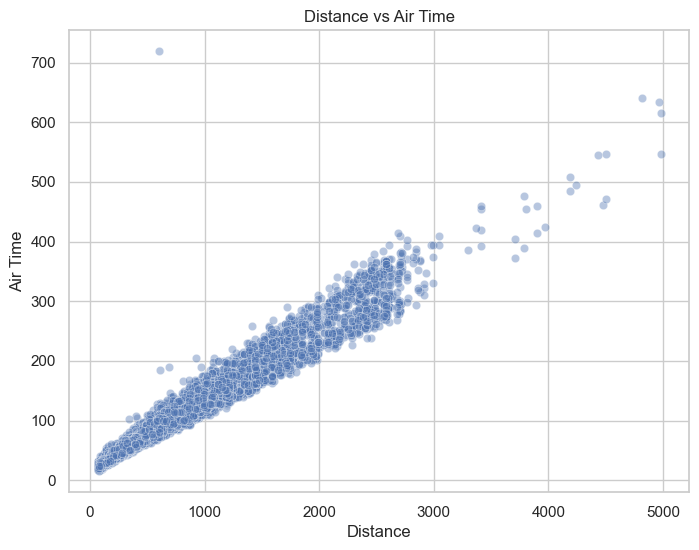

In [248]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=sample_df, x="distance", y="air_time", alpha=0.4)
plt.title("Distance vs Air Time")
plt.xlabel("Distance")
plt.ylabel("Air Time")
plt.show()

# 19. Correlation heatmap

In [249]:
correlation_columns = [
    "dep_delay","arr_delay","air_time","distance",
    "taxi_out","taxi_in","actual_elapsed_time","crs_elapsed_time"
]

In [250]:
correlation = completed_df[correlation_columns].corr()
correlation

,dep_delay,arr_delay,air_time,distance,taxi_out,taxi_in,actual_elapsed_time,crs_elapsed_time
dep_delay,1.000000,0.969316,0.005999,0.005164,0.070552,0.023088,0.019180,0.008458
arr_delay,0.969316,1.000000,0.000570,-0.015471,0.215296,0.111634,0.045575,-0.017762
air_time,0.005999,0.000570,1.000000,0.978828,0.002018,0.046851,0.982007,0.987132
distance,0.005164,-0.015471,0.978828,1.000000,-0.013570,0.037559,0.957947,0.976423
taxi_out,0.070552,0.215296,0.002018,-0.013570,1.000000,0.022657,0.157792,0.028320
taxi_in,0.023088,0.111634,0.046851,0.037559,0.022657,1.000000,0.155841,0.077433
actual_elapsed_time,0.019180,0.045575,0.982007,0.957947,0.157792,0.155841,1.000000,0.976735
crs_elapsed_time,0.008458,-0.017762,0.987132,0.976423,0.028320,0.077433,0.976735,1.000000


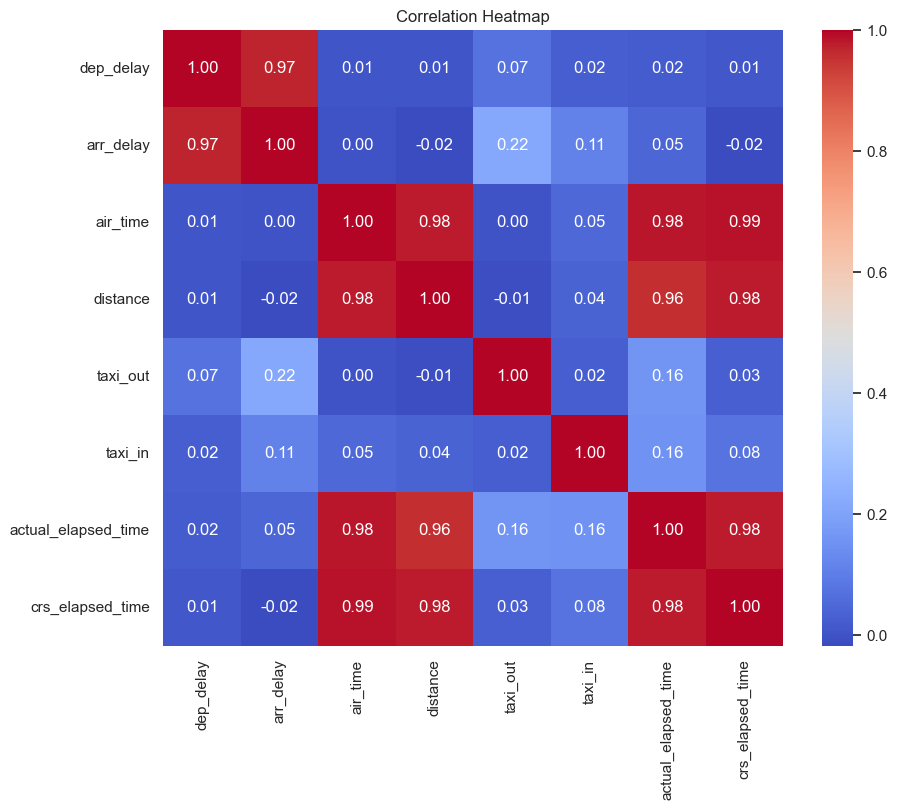

In [251]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 20. Taxi-time analysis

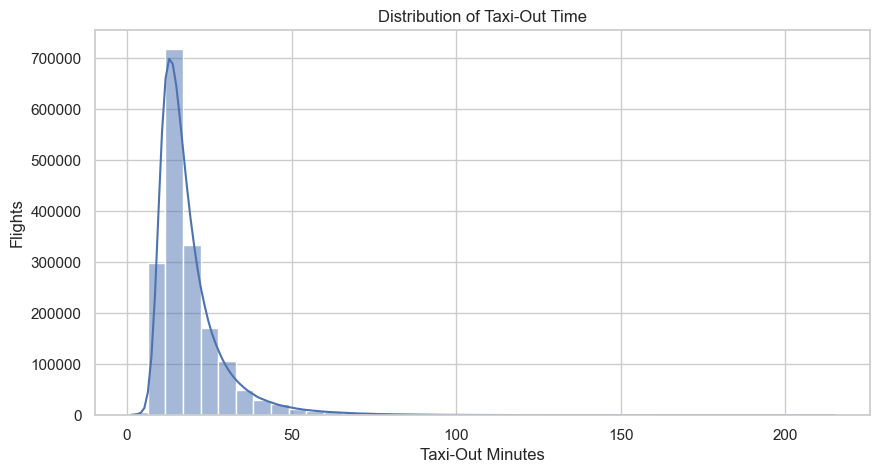

In [252]:
plt.figure(figsize=(10,5))
sns.histplot(completed_df["taxi_out"].dropna(), bins=40, kde=True)
plt.title("Distribution of Taxi-Out Time")
plt.xlabel("Taxi-Out Minutes")
plt.ylabel("Flights")
plt.show()

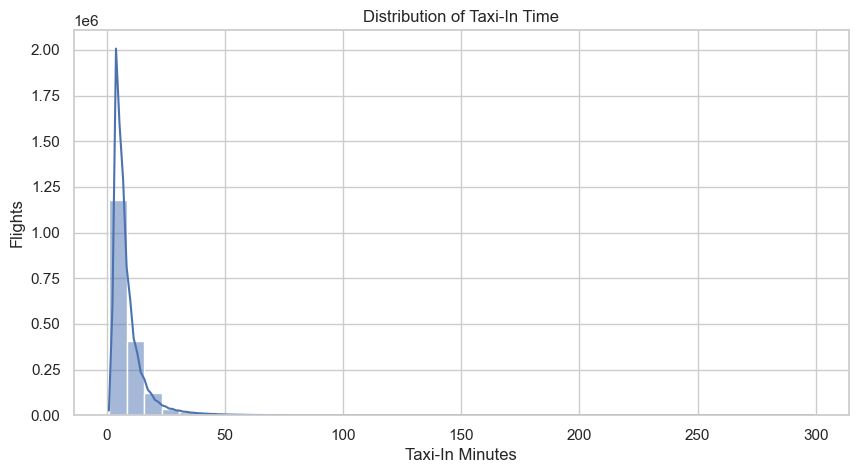

In [253]:
plt.figure(figsize=(10,5))
sns.histplot(completed_df["taxi_in"].dropna(), bins=40, kde=True)
plt.title("Distribution of Taxi-In Time")
plt.xlabel("Taxi-In Minutes")
plt.ylabel("Flights")
plt.show()

# 21. Monthly delay trend

In [254]:
monthly_delay = completed_df.groupby(completed_df["fl_date"].dt.to_period("M"))["arr_delay"].mean()
monthly_delay

fl_date
2026-01     6.464044
2026-02     3.990915
2026-03    10.701591
Freq: M, Name: arr_delay, dtype: float64

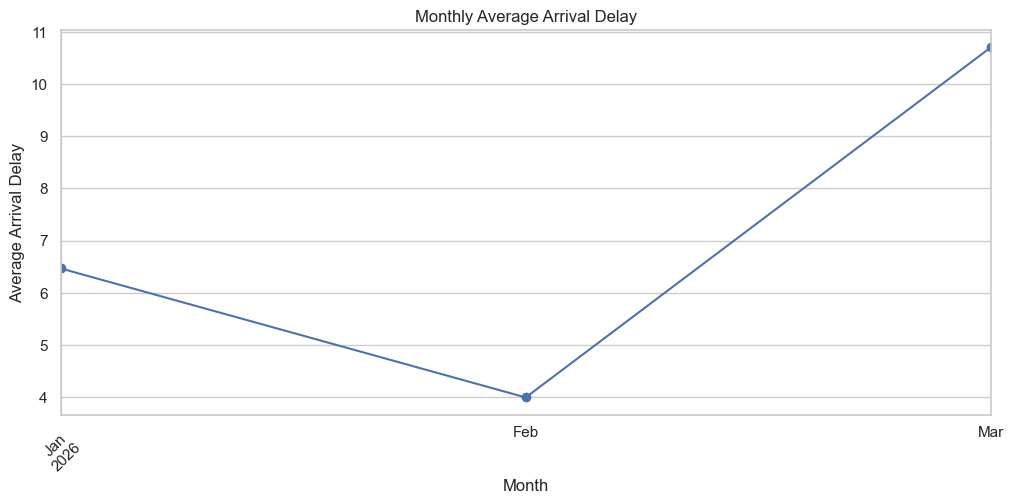

In [255]:
monthly_delay.plot(figsize=(12,5), marker="o")
plt.title("Monthly Average Arrival Delay")
plt.xlabel("Month")
plt.ylabel("Average Arrival Delay")
plt.xticks(rotation=45)
plt.show()

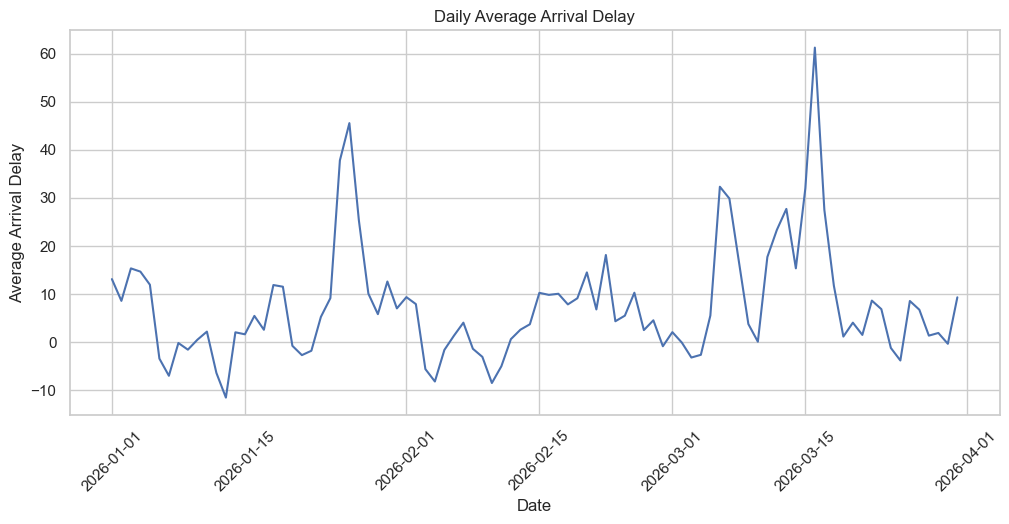

In [256]:
daily_delay = completed_df.groupby("fl_date")["arr_delay"].mean()
plt.figure(figsize=(12,5))
plt.plot(daily_delay.index, daily_delay.values)
plt.title("Daily Average Arrival Delay")
plt.xlabel("Date")
plt.ylabel("Average Arrival Delay")
plt.xticks(rotation=45)
plt.show()

# 22. Day-of-week delay

In [257]:
day_delay = completed_df.groupby("day_of_week")["arr_delay"].mean().reindex(day_order)
day_delay

day_of_week
Monday       10.383226
Tuesday       3.232258
Wednesday     2.706046
Thursday      5.214458
Friday        9.525241
Saturday      7.415880
Sunday       11.468163
Name: arr_delay, dtype: float64

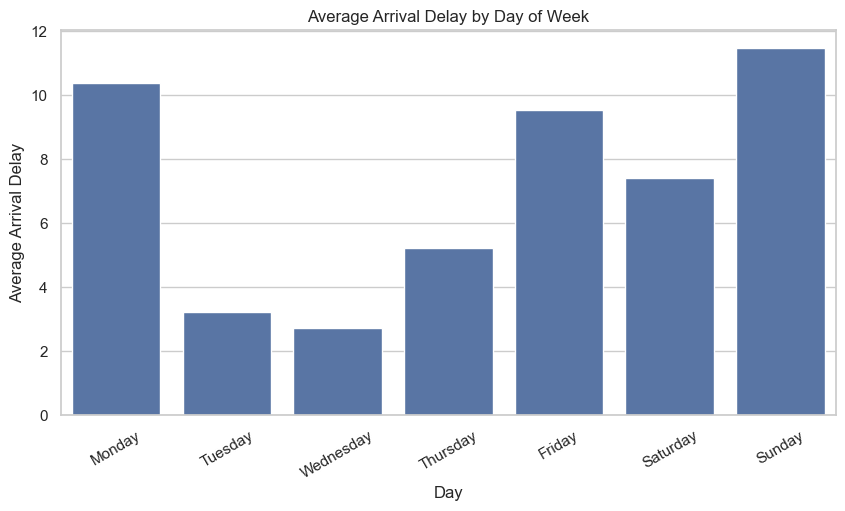

In [258]:
plt.figure(figsize=(10,5))
sns.barplot(x=day_delay.index, y=day_delay.values)
plt.title("Average Arrival Delay by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Arrival Delay")
plt.xticks(rotation=30)
plt.show()

# 23. Monthly cancellation rate

In [259]:
monthly_cancellation_rate = df.groupby(df["fl_date"].dt.to_period("M"))["cancelled"].mean().mul(100)
monthly_cancellation_rate

fl_date
2026-01    4.822598
2026-02    2.346740
2026-03    2.943745
Freq: M, Name: cancelled, dtype: float64

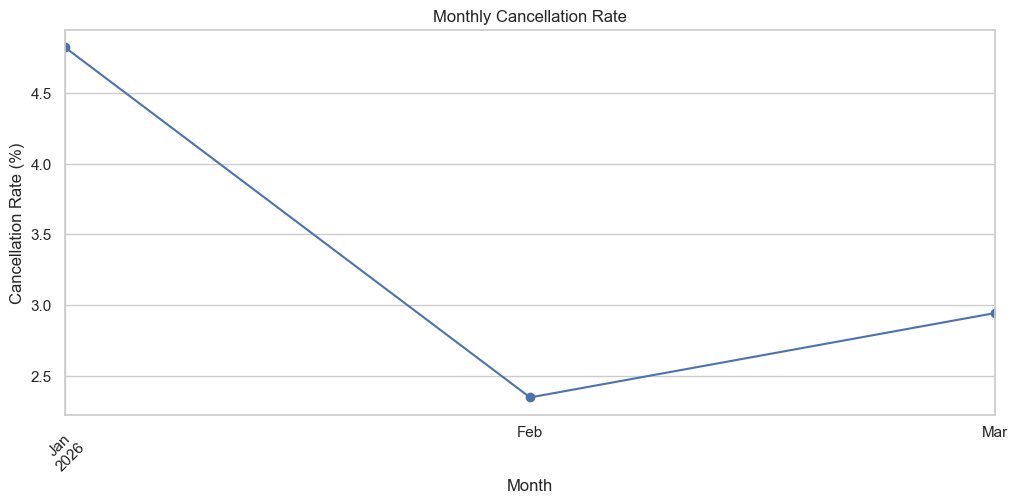

In [260]:
monthly_cancellation_rate.plot(figsize=(12,5), marker="o")
plt.title("Monthly Cancellation Rate")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

# 24. Airline KPI table

In [261]:
airline_kpi = df.groupby("mkt_carrier").agg(
    flights=("mkt_carrier","size"),
    cancelled=("cancelled","sum"),
    diverted=("diverted","sum")
)

In [262]:
airline_kpi["cancellation_rate"] = (
    airline_kpi["cancelled"] / airline_kpi["flights"] * 100
).round(2)

In [263]:
airline_delay_kpi = completed_df.groupby("mkt_carrier").agg(
    avg_dep_delay=("dep_delay","mean"),
    avg_arr_delay=("arr_delay","mean")
)
airline_kpi = airline_kpi.join(airline_delay_kpi)

In [264]:
airline_kpi["arrival_delay_rate"] = (
    completed_df.groupby("mkt_carrier")["arr_delay"]
    .apply(lambda x: (x >= 15).mean() * 100)
)
airline_kpi.sort_values("flights", ascending=False).head(20)

,flights,cancelled,diverted,cancellation_rate,avg_dep_delay,avg_arr_delay,arrival_delay_rate
mkt_carrier,,,,,,,
AA,483902,22945.0,1492.0,4.74,17.090053,10.322157,23.042887
DL,386832,14328.0,840.0,3.70,11.924881,5.853817,20.131893
UA,358108,9204.0,998.0,2.57,12.690776,6.235863,19.804200
WN,327083,5659.0,624.0,1.73,11.368226,3.200954,20.071696
AS,116489,2158.0,386.0,1.85,8.368537,2.175787,18.582650
B6,57320,3010.0,153.0,5.25,19.758351,15.625995,31.207415
F9,50557,1405.0,81.0,2.78,18.359581,13.014408,26.753072
NK,36379,3123.0,55.0,8.58,24.656486,19.661396,35.423632
G4,30572,479.0,108.0,1.57,16.772686,13.490645,24.929131


# 25. Airport KPI table

In [265]:
airport_kpi = df.groupby("origin").agg(
    flights=("origin","size"),
    cancelled=("cancelled","sum"),
    diverted=("diverted","sum")
)

In [266]:
airport_kpi["cancellation_rate"] = (
    airport_kpi["cancelled"] / airport_kpi["flights"] * 100
).round(2)

In [267]:
airport_delay_kpi = completed_df.groupby("origin").agg(
    avg_dep_delay=("dep_delay","mean"),
    avg_arr_delay=("arr_delay","mean")
)
airport_kpi = airport_kpi.join(airport_delay_kpi)
airport_kpi.sort_values("flights", ascending=False).head(20)

,flights,cancelled,diverted,cancellation_rate,avg_dep_delay,avg_arr_delay
origin,,,,,,
ORD,88327,3269.0,267.0,3.70,21.624146,17.835183
ATL,82965,2736.0,207.0,3.30,11.645772,8.282797
DEN,74619,1023.0,180.0,1.37,12.343427,4.070897
DFW,72321,3330.0,205.0,4.60,17.136467,10.481290
CLT,55461,3010.0,164.0,5.43,13.322795,5.488075
PHX,51866,682.0,141.0,1.31,11.237976,5.074937
LAX,45488,745.0,139.0,1.64,11.342839,5.032934
MCO,42632,1495.0,92.0,3.51,17.231624,11.412864
LAS,42030,557.0,89.0,1.33,10.851609,3.108109


# 26. Route KPI table

In [268]:
# route_kpi = completed_df.groupby("route").agg(
#     flights=("route","size"),
#     avg_arr_delay=("arr_delay","mean")
# )

In [269]:
# route_kpi["delay_rate"] = (
#     completed_df.groupby("route")["arr_delay"]
#     .apply(lambda x: (x >= 15).mean() * 100)
# )
# route_kpi.sort_values("flights", ascending=False).head(20)

In [270]:
# route_kpi.sort_values("delay_rate", ascending=False).head(20)

# 27. Business questions — final checks

## Q1. Which airlines have the highest cancellation rate?

In [271]:
airline_kpi.sort_values("cancellation_rate", ascending=False).head(10)

,flights,cancelled,diverted,cancellation_rate,avg_dep_delay,avg_arr_delay,arrival_delay_rate
mkt_carrier,,,,,,,
NK,36379,3123.0,55.0,8.58,24.656486,19.661396,35.423632
B6,57320,3010.0,153.0,5.25,19.758351,15.625995,31.207415
AA,483902,22945.0,1492.0,4.74,17.090053,10.322157,23.042887
DL,386832,14328.0,840.0,3.70,11.924881,5.853817,20.131893
F9,50557,1405.0,81.0,2.78,18.359581,13.014408,26.753072
UA,358108,9204.0,998.0,2.57,12.690776,6.235863,19.804200
AS,116489,2158.0,386.0,1.85,8.368537,2.175787,18.582650
WN,327083,5659.0,624.0,1.73,11.368226,3.200954,20.071696
G4,30572,479.0,108.0,1.57,16.772686,13.490645,24.929131


## Q2. Which airlines have the highest arrival-delay rate?

In [272]:
airline_kpi.sort_values("arrival_delay_rate", ascending=False).head(10)

,flights,cancelled,diverted,cancellation_rate,avg_dep_delay,avg_arr_delay,arrival_delay_rate
mkt_carrier,,,,,,,
NK,36379,3123.0,55.0,8.58,24.656486,19.661396,35.423632
B6,57320,3010.0,153.0,5.25,19.758351,15.625995,31.207415
F9,50557,1405.0,81.0,2.78,18.359581,13.014408,26.753072
G4,30572,479.0,108.0,1.57,16.772686,13.490645,24.929131
AA,483902,22945.0,1492.0,4.74,17.090053,10.322157,23.042887
DL,386832,14328.0,840.0,3.70,11.924881,5.853817,20.131893
WN,327083,5659.0,624.0,1.73,11.368226,3.200954,20.071696
UA,358108,9204.0,998.0,2.57,12.690776,6.235863,19.804200
AS,116489,2158.0,386.0,1.85,8.368537,2.175787,18.582650


## Q3. Which airports have the highest departure delay?

In [273]:
airport_kpi.sort_values("avg_dep_delay", ascending=False).head(15)

,flights,cancelled,diverted,cancellation_rate,avg_dep_delay,avg_arr_delay
origin,,,,,,
PAH,72,1.0,0.0,1.39,75.352113,61.521127
ART,180,9.0,1.0,5.00,71.723529,70.388235
JST,179,15.0,1.0,8.38,66.932515,64.889571
MQT,314,36.0,0.0,11.46,57.000000,49.543165
IMT,180,14.0,0.0,7.78,55.807229,47.349398
BGM,45,2.0,0.0,4.44,48.093023,37.813953
LWB,70,7.0,0.0,10.00,47.682540,46.000000
HGR,52,0.0,0.0,0.00,47.346154,38.923077
EAU,153,9.0,0.0,5.88,44.930556,46.076389


## Q4. Which routes have the highest delay rate?

In [274]:
# route_kpi.sort_values("delay_rate", ascending=False).head(15)

## Q5. What is the biggest source of delay?

In [275]:
print("Largest delay cause:", delay_totals.idxmax())
print("Delay minutes:", delay_totals.max())

Largest delay cause: late_aircraft_delay
Delay minutes: 11252035.0


## Q6. Are delays getting worse or better over time?

In [276]:
monthly_delay.diff().tail(12)

fl_date
2026-01         NaN
2026-02   -2.473129
2026-03    6.710676
Freq: M, Name: arr_delay, dtype: float64

## Q7. Do departure delays carry into arrival delays?

In [277]:
corr_value = completed_df[["dep_delay","arr_delay"]].corr().loc["dep_delay","arr_delay"]
print("Correlation:", round(corr_value,2))

Correlation: 0.97


# 28. Final professional insight framework

For the final project presentation, convert the analysis into:

**Finding → Evidence → Business impact → Recommendation**

Example:

> Carrier-related delays are a major contributor to total delay minutes.  
> The evidence comes from the delay-cause aggregation.  
> This can reduce on-time performance and create downstream disruption.  
> Operations teams should investigate the highest-impact carriers, airports and routes.

Do not claim causation from correlation alone. Always connect the finding to the supporting KPI or chart.

# ✅ EDA COMPLETE

The cleaned dataset is now ready for:

**EDA → Business Insights → Power BI Dashboard → Root-Cause Analysis → Recommendations**

The most important outputs to carry into the dashboard are:

- Total flights
- Cancellation rate
- Diversion rate
- Departure delay rate
- Arrival delay rate
- Average delays
- Airline performance
- Airport hotspots
- Route hotspots
- Delay causes
- Monthly trends
- Outlier/extreme-delay monitoring

# 28. Final professional interpretation

Use the results above to write business findings rather than simply listing charts.

**Finding → Evidence → Business impact → Recommendation**

Example:

> Carrier delay is a major contributor to total delay minutes. The evidence comes from the delay-cause analysis. This can reduce on-time performance, so the operations team should investigate the highest-impact carriers, airports and routes.

### Important rules
- Do not automatically delete IQR outliers.
- Use a minimum flight count when comparing small airlines, airports or routes.
- Treat legitimate missing values differently from incorrect missing values.
- Correlation does not prove causation.
- The purpose of EDA is to answer business questions and support decisions.


# ✅ EDA COMPLETE

**Raw Data → Data Cleaning → Cleaned Data → EDA → KPI's → Business Questions → Insights → Power BI Dashboard**

This notebook is intentionally **professional but beginner-friendly**. It focuses on useful airline operational analysis instead of unnecessary advanced techniques.
